#US Housing Market Analysis (EDA Project)


## Introduction:
This project explores housing data to identify patterns and factors influencing property prices.

## Data Overview
The dataset contains 3,000 housing listings with features such as price, location, number of bedrooms, bathrooms, square footage, and days on market.

In [80]:
import pandas as pd

df = pd.read_csv("us_house_Sales_data.csv")
df.head()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           3000 non-null   object
 1   Address         3000 non-null   object
 2   City            3000 non-null   object
 3   Zipcode         3000 non-null   int64 
 4   State           3000 non-null   object
 5   Bedrooms        3000 non-null   object
 6   Bathrooms       3000 non-null   object
 7   Area (Sqft)     3000 non-null   object
 8   Lot Size        3000 non-null   object
 9   Year Built      3000 non-null   int64 
 10  Days on Market  3000 non-null   int64 
 11  Property Type   3000 non-null   object
 12  MLS ID          3000 non-null   object
 13  Listing Agent   3000 non-null   object
 14  Status          3000 non-null   object
 15  Listing URL     3000 non-null   object
dtypes: int64(3), object(13)
memory usage: 375.1+ KB


In [82]:
df.isnull().sum()

,0
Price,0
Address,0
City,0
Zipcode,0
State,0
Bedrooms,0
Bathrooms,0
Area (Sqft),0
Lot Size,0
Year Built,0


## Data Cleaning
The dataset contained text-based values for key features such as price, bedrooms, bathrooms, and area. These were cleaned and converted into numerical format to enable analysis.

In [83]:
df_clean = df.copy()

# Clean Price
df_clean["Price"] = df_clean["Price"].replace(r"[\$,]", "", regex=True).astype(float)

# Clean Bedrooms
df_clean["Bedrooms"] = df_clean["Bedrooms"].str.extract(r"(\d+)").astype(float)

# Clean Bathrooms
df_clean["Bathrooms"] = df_clean["Bathrooms"].str.extract(r"(\d+(\.\d+)?)")[0].astype(float)

# Clean Area (Sqft)
df_clean["Area (Sqft)"] = df_clean["Area (Sqft)"].replace(r"[^\d]", "", regex=True).astype(float)

# Clean Lot Size
df_clean["Lot Size"] = df_clean["Lot Size"].replace(r"[^\d]", "", regex=True).astype(float)

df_clean.head()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,554217.0,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1.0,3.0,772.0,4757.0,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,164454.0,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1.0,1.0,2348.0,3615.0,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,1249331.0,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6.0,1.0,3630.0,9369.0,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,189267.0,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2.0,1.0,605.0,8804.0,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,465778.0,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3.0,2.0,1711.0,9260.0,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/


In [84]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Price           3000 non-null   float64
 1   Address         3000 non-null   object 
 2   City            3000 non-null   object 
 3   Zipcode         3000 non-null   int64  
 4   State           3000 non-null   object 
 5   Bedrooms        3000 non-null   float64
 6   Bathrooms       3000 non-null   float64
 7   Area (Sqft)     3000 non-null   float64
 8   Lot Size        3000 non-null   float64
 9   Year Built      3000 non-null   int64  
 10  Days on Market  3000 non-null   int64  
 11  Property Type   3000 non-null   object 
 12  MLS ID          3000 non-null   object 
 13  Listing Agent   3000 non-null   object 
 14  Status          3000 non-null   object 
 15  Listing URL     3000 non-null   object 
dtypes: float64(5), int64(3), object(8)
memory usage: 375.1+ KB


## Price Distribution

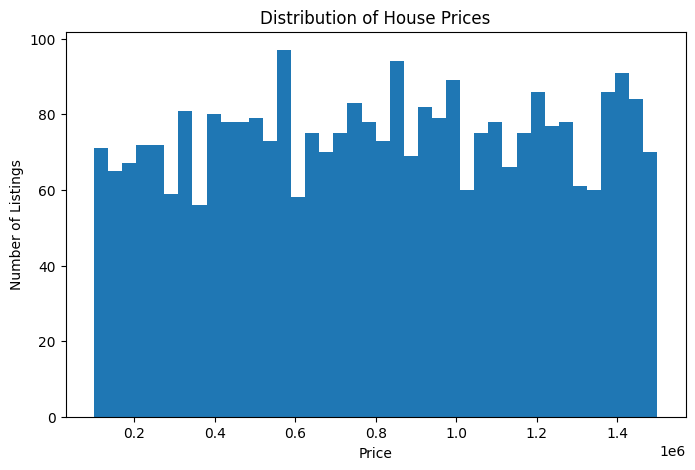

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["Price"], bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

### Insight
The distribution of house prices appears relatively uniform across the range, suggesting that listings are evenly distributed rather than concentrated in a specific price band. This may indicate a balanced dataset rather than a naturally skewed real estate market.

## Price vs Area (Sqft)

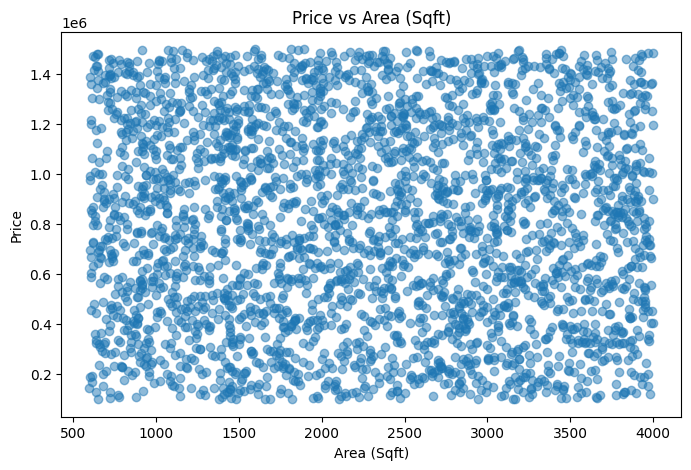

In [86]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["Area (Sqft)"], df_clean["Price"], alpha=0.5)
plt.title("Price vs Area (Sqft)")
plt.xlabel("Area (Sqft)")
plt.ylabel("Price")
plt.show()

### Insight
The analysis shows little to no correlation between square footage and house price, with a correlation coefficient close to zero. This indicates that, in this dataset, property size does not significantly influence pricing. This may suggest that the data is either synthetic or that other factors such as location or property type play a larger role in determining price.

In [87]:
df_clean["Price"].corr(df_clean["Area (Sqft)"])

np.float64(-0.03206238803804437)

In [88]:
numeric_cols = ["Price", "Bedrooms", "Bathrooms", "Area (Sqft)", "Lot Size", "Year Built", "Days on Market"]

corr_matrix = df_clean[numeric_cols].corr()
corr_matrix

,Price,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market
Price,1.000000,-0.021533,0.009461,-0.032062,-0.043642,-0.004858,0.003684
Bedrooms,-0.021533,1.000000,-0.017568,-0.028849,-0.009010,0.008503,0.037538
Bathrooms,0.009461,-0.017568,1.000000,0.013145,-0.005501,0.015027,-0.029885
Area (Sqft),-0.032062,-0.028849,0.013145,1.000000,-0.020118,-0.012187,0.036724
Lot Size,-0.043642,-0.009010,-0.005501,-0.020118,1.000000,0.018149,-0.039034
Year Built,-0.004858,0.008503,0.015027,-0.012187,0.018149,1.000000,-0.013330
Days on Market,0.003684,0.037538,-0.029885,0.036724,-0.039034,-0.013330,1.000000


## Correlation Analysis

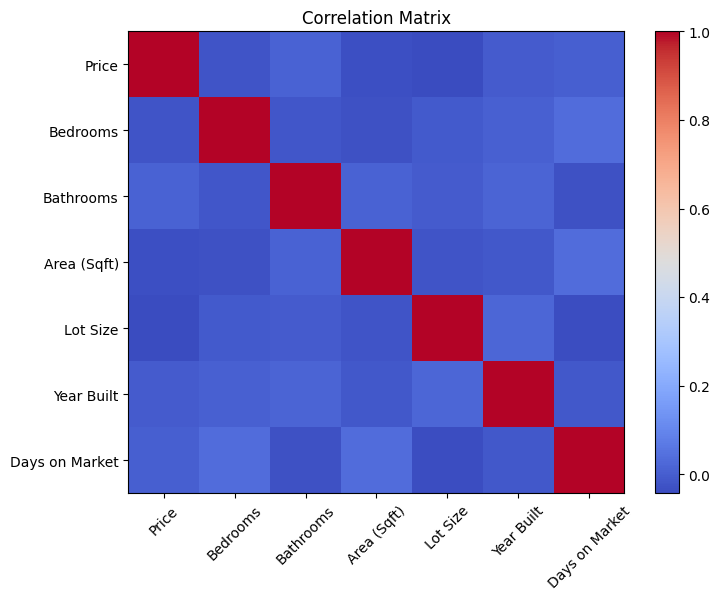

In [89]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation Matrix")
plt.show()

### Insight
The correlation matrix indicates that there are no strong linear relationships between house price and the available features such as bedrooms, bathrooms, square footage, or lot size. This suggests that pricing in this dataset is not driven by a single dominant factor, and may instead depend on a combination of variables or non-linear relationships.

## City-Based Analysis

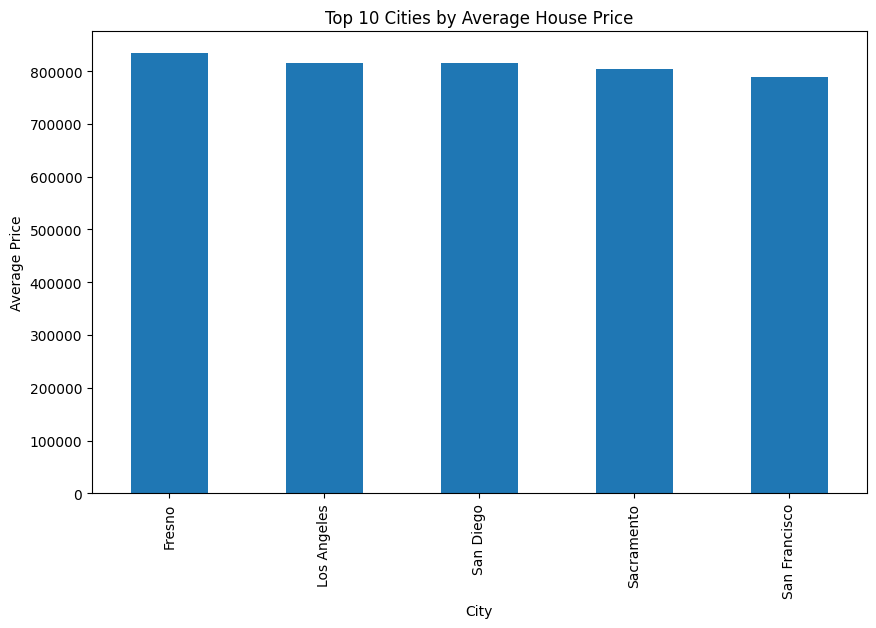

In [90]:
top_cities = df_clean.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Average House Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.show()

### Insight
The analysis of average house prices by city shows minimal variation across locations, with all major cities exhibiting similar price levels. This suggests that location does not significantly influence pricing within this dataset, which may indicate uniform data distribution or synthetic data generation.

In [91]:
df_clean["City"].value_counts().head(10)

,count
City,
Los Angeles,617
Sacramento,609
San Francisco,605
San Diego,586
Fresno,583


## Bedrooms vs Price

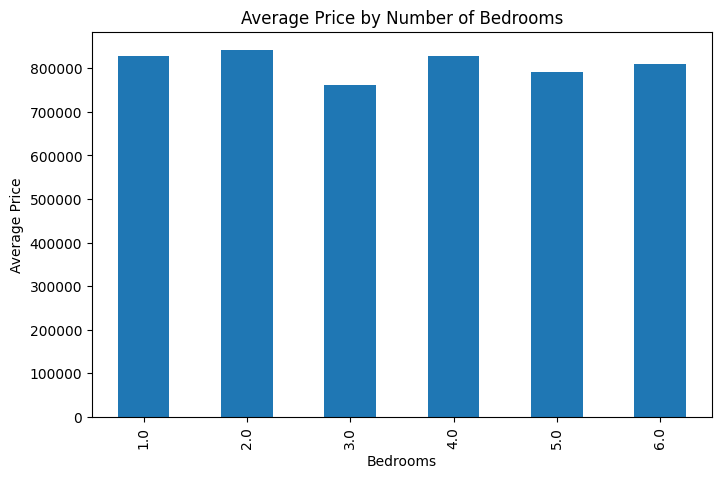

In [92]:
avg_price_bedrooms = df_clean.groupby("Bedrooms")["Price"].mean().sort_index()

plt.figure(figsize=(8,5))
avg_price_bedrooms.plot(kind="bar")
plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.show()

### Insight
Average house prices remain relatively consistent across different bedroom counts, indicating that bedroom quantity alone does not significantly impact pricing in this dataset.

## Conclusion

This analysis explored various factors affecting house prices, including size, location, and property features. The findings show that no single variable strongly predicts price, suggesting that housing prices may depend on a combination of factors or non-linear relationships.

This project demonstrates the importance of exploratory data analysis in understanding datasets before applying predictive modeling.